In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit



train    = pd.read_csv("C:/Users/kprab/OneDrive/Documents/TCD/Projects/Walmart sales forecast/train.csv",    parse_dates=["Date"])
test     = pd.read_csv("C:/Users/kprab/OneDrive/Documents/TCD/Projects/Walmart sales forecast/test.csv",     parse_dates=["Date"])
features = pd.read_csv("C:/Users/kprab/OneDrive/Documents/TCD/Projects/Walmart sales forecast/features.csv" , parse_dates=["Date"])
stores   = pd.read_csv("C:/Users/kprab/OneDrive/Documents/TCD/Projects/Walmart sales forecast/stores.csv")

print(train.shape, test.shape, features.shape, stores.shape)


(421570, 5) (115064, 4) (8190, 12) (45, 3)


In [24]:
# ============================================
# 2️⃣  Merge datasets
# ============================================
def prep_base(df):
    out = df.merge(features, on=["Store","Date"], how="left")
    out = out.merge(stores, on="Store", how="left")
    return out

train_m = prep_base(train)
test_m  = prep_base(test)

# Clean duplicate IsHoliday columns
for df in [train_m, test_m]:
    if "IsHoliday_x" in df.columns:
        df["IsHoliday"] = df["IsHoliday_x"]
    df.drop(columns=["IsHoliday_x","IsHoliday_y"], errors="ignore", inplace=True)

# Fill NaNs in MarkDown columns (means no promotion)
for col in [f"MarkDown{i}" for i in range(1,6)]:
    if col in train_m.columns:
        train_m[col] = train_m[col].fillna(0)
        test_m[col]  = test_m[col].fillna(0)

print("✅ Merge complete.")


✅ Merge complete.


In [26]:
# ============================================
# 3️⃣  Add Time Features
# ============================================
def add_time_features(df):
    d = df.copy()
    d["year"] = d["Date"].dt.year
    d["month"] = d["Date"].dt.month
    d["week"] = d["Date"].dt.isocalendar().week.astype(int)
    d["quarter"] = d["Date"].dt.quarter
    d["is_month_end"] = d["Date"].dt.is_month_end.astype(int)
    d["is_month_start"] = d["Date"].dt.is_month_start.astype(int)
    d["is_year_end"] = d["Date"].dt.is_year_end.astype(int)
    d["is_year_start"] = d["Date"].dt.is_year_start.astype(int)
    return d

train_m = add_time_features(train_m)
test_m  = add_time_features(test_m)


In [28]:
# ============================================
# 4️⃣  Add Lag & Rolling Features
# ============================================
def add_lags_rolls_v2(df, group_cols=["Store", "Dept"], target="Weekly_Sales"):
    d = df.copy()
    if target in d.columns:
        d[target] = d[target].astype(float)
    else:
        d[target] = np.nan

    # Simple lags
    d["lag_1"]  = d.groupby(group_cols)[target].shift(1)
    d["lag_2"]  = d.groupby(group_cols)[target].shift(2)
    d["lag_4"]  = d.groupby(group_cols)[target].shift(4)
    d["lag_8"]  = d.groupby(group_cols)[target].shift(8)
    d["lag_52"] = d.groupby(group_cols)[target].shift(52)

    # Rolling means
    d["roll_mean_4"]  = d.groupby(group_cols)[target].transform(lambda s: s.shift(1).rolling(4).mean())
    d["roll_mean_8"]  = d.groupby(group_cols)[target].transform(lambda s: s.shift(1).rolling(8).mean())
    d["roll_mean_52"] = d.groupby(group_cols)[target].transform(lambda s: s.shift(1).rolling(52).mean())

    # Rolling stds
    d["roll_std_4"]   = d.groupby(group_cols)[target].transform(lambda s: s.shift(1).rolling(4).std())
    d["roll_std_8"]   = d.groupby(group_cols)[target].transform(lambda s: s.shift(1).rolling(8).std())

    return d

train_feat = add_lags_rolls_v2(train_m)
test_feat  = add_lags_rolls_v2(test_m)


In [30]:
# ============================================
# 5️⃣  Fill NaNs & Encode Categoricals
# ============================================
for df in [train_feat, test_feat]:
    for col in df.select_dtypes(include="number").columns:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical columns
cat_cols = train_feat.select_dtypes(exclude=["number","datetime64[ns]"]).columns
for c in cat_cols:
    cats = pd.Categorical(train_feat[c].astype(str))
    train_feat[c] = cats.codes
    mapping = {cat: code for code, cat in enumerate(cats.categories)}
    test_feat[c] = test_feat[c].astype(str).map(mapping).fillna(-1).astype(int)


In [32]:
# ============================================
# 6️⃣  Prepare Train/Test Data
# ============================================
X = train_feat.drop(columns=["Weekly_Sales", "Date"], errors="ignore")
y = train_feat["Weekly_Sales"].values
X_test = test_feat.drop(columns=["Date"], errors="ignore")

# Align columns
X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)

# Weighted holidays (5x)
weights = np.where(train_feat["IsHoliday"].astype(int)==1, 5, 1)


In [36]:
import lightgbm as lgb


In [38]:
# ============================================
# 7️⃣  Train Final Model (Log-Transformed Target)
# ============================================
y_log = np.log1p(y)  # log(1 + Weekly_Sales)

final_model = lgb.LGBMRegressor(
    objective="mae",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("⏳ Training LightGBM (log target)...")
final_model.fit(X, y_log, sample_weight=weights)
print("✅ Training complete!")


C:\Users\kprab\AppData\Local\Temp\ipykernel_196\2014911095.py:4: RuntimeWarning: divide by zero encountered in log1p
  y_log = np.log1p(y)  # log(1 + Weekly_Sales)
C:\Users\kprab\AppData\Local\Temp\ipykernel_196\2014911095.py:4: RuntimeWarning: invalid value encountered in log1p
  y_log = np.log1p(y)  # log(1 + Weekly_Sales)


⏳ Training LightGBM (log target)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5088
[LightGBM] [Info] Number of data points in the train set: 421570, number of used features: 31
[LightGBM] [Info] Start training from score 8.946589
✅ Training complete!


In [40]:
# ============================================
# 8️⃣  Predict & Create Submission
# ============================================
test_pred_log = final_model.predict(X_test)
test_pred = np.expm1(test_pred_log)  # reverse log-transform (always positive)

test_feat["Weekly_Sales"] = test_pred
test_feat["Id"] = (
    test_feat["Store"].astype(str) + "_" +
    test_feat["Dept"].astype(str) + "_" +
    test_feat["Date"].dt.date.astype(str)
)

submission = test_feat[["Id", "Weekly_Sales"]]
submission.to_csv("submission_lightgbm_log.csv", index=False)
print("submission_lightgbm_log.csv created successfully!")


submission_lightgbm_log.csv created successfully!


C:\Users\kprab\AppData\Local\Temp\ipykernel_196\1307157195.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\kprab\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


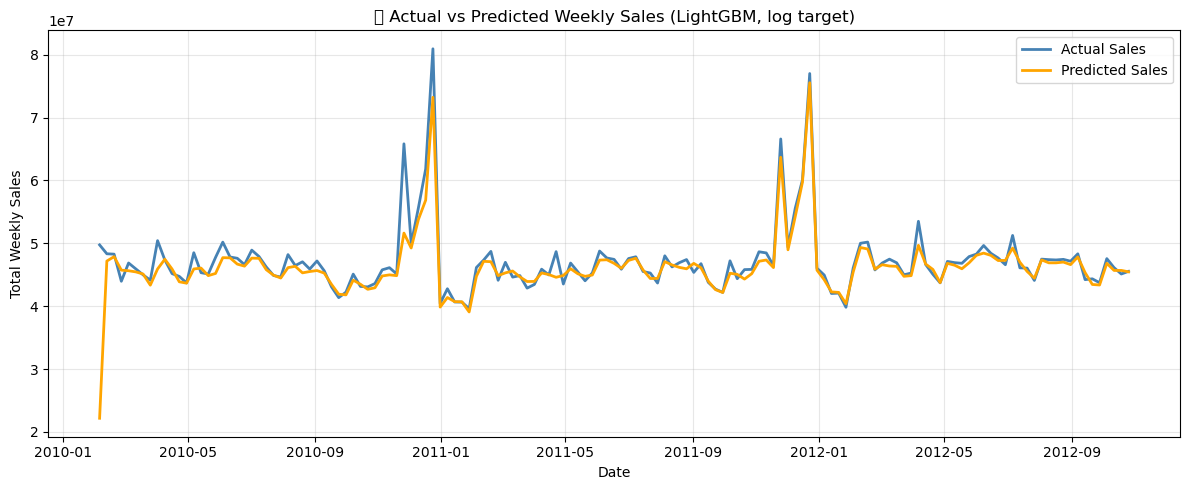

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# --- Predict on training data (reverse log) ---
train_pred_log = final_model.predict(X)
train_pred = np.expm1(train_pred_log)   # convert back to actual scale

# --- Combine into DataFrame ---
train_plot = pd.DataFrame({
    "Date": train_feat["Date"],
    "Actual": train_feat["Weekly_Sales"],
    "Predicted": train_pred
})

# --- Aggregate by week (to make it smoother) ---
weekly = train_plot.groupby("Date")[["Actual", "Predicted"]].sum()

# --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(weekly.index, weekly["Actual"], label="Actual Sales", color="steelblue", linewidth=2)
plt.plot(weekly.index, weekly["Predicted"], label="Predicted Sales", color="orange", linewidth=2)
plt.title("📈 Actual vs Predicted Weekly Sales (LightGBM, log target)")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [46]:
# --- Clean up NaN or Inf values before validation ---
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y_log = pd.Series(y_log).fillna(0)
weights = np.nan_to_num(weights, nan=1.0)


In [48]:
from sklearn.metrics import mean_absolute_error

train_pred_log = final_model.predict(X)
train_pred = np.expm1(train_pred_log)
train_mae = mean_absolute_error(np.expm1(y_log), train_pred)
print(f"Training MAE: {train_mae:,.2f}")


Training MAE: 1,476.44


In [50]:
split = int(0.9 * len(X))
X_tr, X_val = X.iloc[:split].copy(), X.iloc[split:].copy()
y_tr, y_val = y_log[:split], y_log[split:]

# Clean NaNs in split sets
X_tr.fillna(0, inplace=True)
X_val.fillna(0, inplace=True)
y_tr = pd.Series(y_tr).fillna(0)
y_val = pd.Series(y_val).fillna(0)

# Train new model on training slice only
model_val = lgb.LGBMRegressor(**final_model.get_params())
model_val.fit(X_tr, y_tr)
pred_val = np.expm1(model_val.predict(X_val))
val_mae = mean_absolute_error(np.expm1(y_val), pred_val)

print(f"Validation MAE: {val_mae:,.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5084
[LightGBM] [Info] Number of data points in the train set: 379413, number of used features: 31
[LightGBM] [Info] Start training from score 8.969687
Validation MAE: 1,105.71


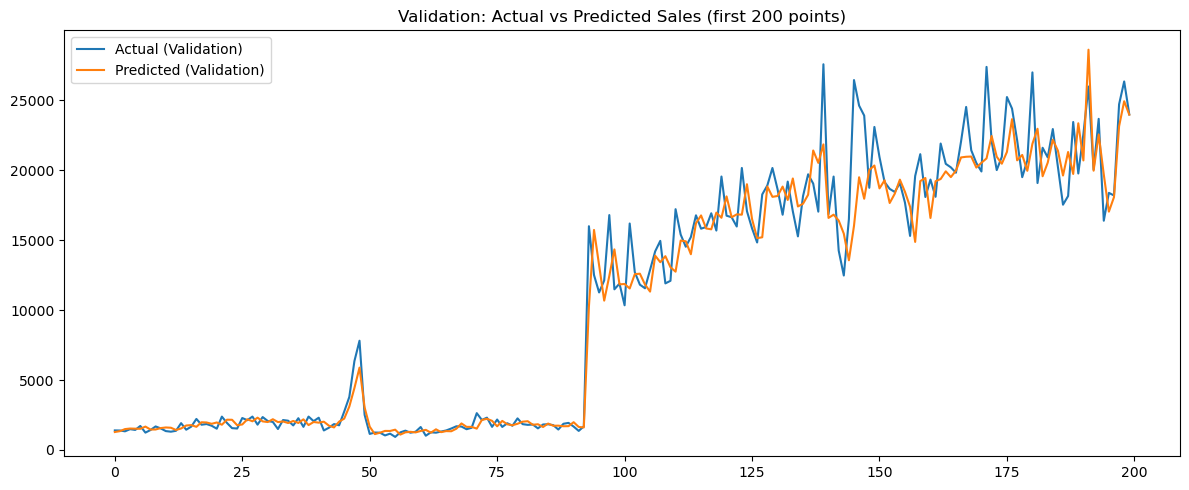

In [51]:
plt.figure(figsize=(12,5))
plt.plot(np.expm1(y_val).values[:200], label="Actual (Validation)")
plt.plot(pred_val[:200], label="Predicted (Validation)")
plt.title("Validation: Actual vs Predicted Sales (first 200 points)")
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
print(f"Training MAE: {train_mae:,.2f}")
print(f"Validation MAE: {val_mae:,.2f}")


Training MAE: 1,476.44
Validation MAE: 1,105.71
